In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns if needed
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("/Users/akashkumarsamantray/Desktop/amz_uk_price_prediction_dataset.csv")
df

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2443646,2828589,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,False,0,Motorbike Clothing
2443647,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,False,0,Motorbike Clothing
2443648,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,False,0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing


In [ ]:
## Part 1: Analyzing Best-Seller Trends Across Product Categories

In [ ]:
## Crosstab Analysis

In [3]:
category_bestseller_ct = pd.crosstab(
    df['category'],
    df['isBestSeller']
)

category_bestseller_ct.head()

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3


In [ ]:
## Calculate the Proportion of Best Sellers

In [4]:
bestseller_proportion = pd.crosstab(
    df['category'],
    df['isBestSeller'],
    normalize='index'
) * 100

bestseller_proportion.head()

isBestSeller,False,True
category,,
3D Printers,99.596774,0.403226
3D Printing & Scanning,99.950824,0.049176
Abrasive & Finishing Products,98.000000,2.000000
Action Cameras,99.941072,0.058928
Adapters,98.818898,1.181102


In [ ]:
## Sort Categories by Best-Seller Percentage

In [5]:
bestseller_sorted = (
    bestseller_proportion[True]
    .sort_values(ascending=False)
)

bestseller_sorted.head(20)

category
Grocery                           5.813467
Smart Home Security & Lighting    5.769231
Health & Personal Care            5.768628
Mobile Phone Accessories          4.247104
Power & Hand Tools                3.533895
Billiard, Snooker & Pool          3.212851
Pet Supplies                      3.020028
Home Brewing & Wine Making        2.845528
Wind Instruments                  2.800000
Mirrors                           2.800000
Professional Medical Supplies     2.734375
PC & Video Games                  2.546634
Bakeware                          2.510460
Material Handling Products        2.500000
Bedding Accessories               2.439024
Tableware                         2.409639
Arts & Crafts                     2.408629
Baby                              2.265781
Lighting                          2.255639
Window Treatments                 2.092050
Name: True, dtype: float64

In [ ]:
## Display Top Categories

In [6]:
top_bestseller_categories = bestseller_sorted.head(10)

print(top_bestseller_categories)

category
Grocery                           5.813467
Smart Home Security & Lighting    5.769231
Health & Personal Care            5.768628
Mobile Phone Accessories          4.247104
Power & Hand Tools                3.533895
Billiard, Snooker & Pool          3.212851
Pet Supplies                      3.020028
Home Brewing & Wine Making        2.845528
Wind Instruments                  2.800000
Mirrors                           2.800000
Name: True, dtype: float64


In [ ]:
## Visualization

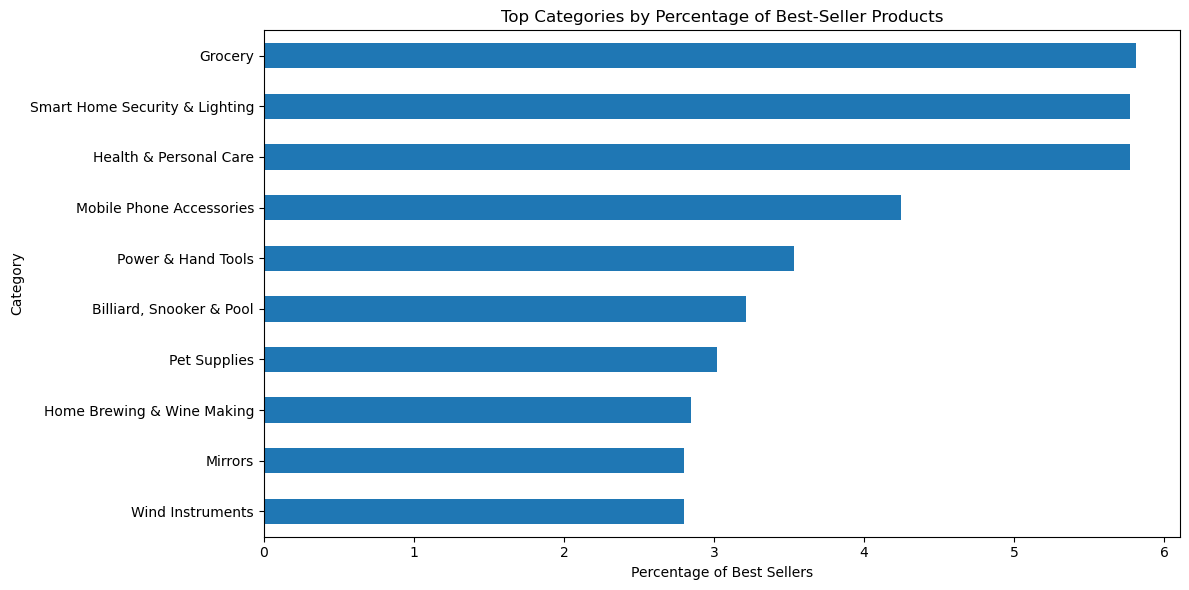

In [7]:
plt.figure(figsize=(12,6))

top_bestseller_categories.sort_values().plot(
    kind='barh'
)

plt.title('Top Categories by Percentage of Best-Seller Products')
plt.xlabel('Percentage of Best Sellers')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

In [ ]:
## Statistical Tests:

In [ ]:
## Create the Contingency Table

In [8]:
contingency_table = pd.crosstab(
    df['category'],
    df['isBestSeller']
)

contingency_table.head()

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3


In [ ]:
## Perform the Chi-Square Test

In [9]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 36540.20270061387
P-value: 0.0
Degrees of Freedom: 295


In [ ]:
## Interpret the Chi-Square Test

In [10]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Reject the null hypothesis


In [ ]:
## Calculate Cramér's V

In [11]:
import numpy as np

n = contingency_table.sum().sum()

min_dim = min(
    contingency_table.shape[0] - 1,
    contingency_table.shape[1] - 1
)

cramers_v = np.sqrt(
    chi2 / (n * min_dim)
)

print("Cramer's V:", cramers_v)

Cramer's V: 0.1222829439760564


In [ ]:
## Visualizations:

In [13]:
category_bestseller = pd.crosstab(
    df['category'],
    df['isBestSeller']
)

category_bestseller.head()

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3


In [14]:
top_categories = df['category'].value_counts().head(10).index

category_bestseller_top = pd.crosstab(
    df[df['category'].isin(top_categories)]['category'],
    df[df['category'].isin(top_categories)]['isBestSeller']
)

category_bestseller_top

isBestSeller,False,True
category,,
Bath & Body,19059,33
Beauty,19010,302
Birthday Gifts,18943,35
Fragrances,18550,14
Hair Care,18665,70
"Handmade Clothing, Shoes & Accessories",19215,14
Make-up,18715,41
Manicure & Pedicure Products,18882,58
Skin Care,18711,58


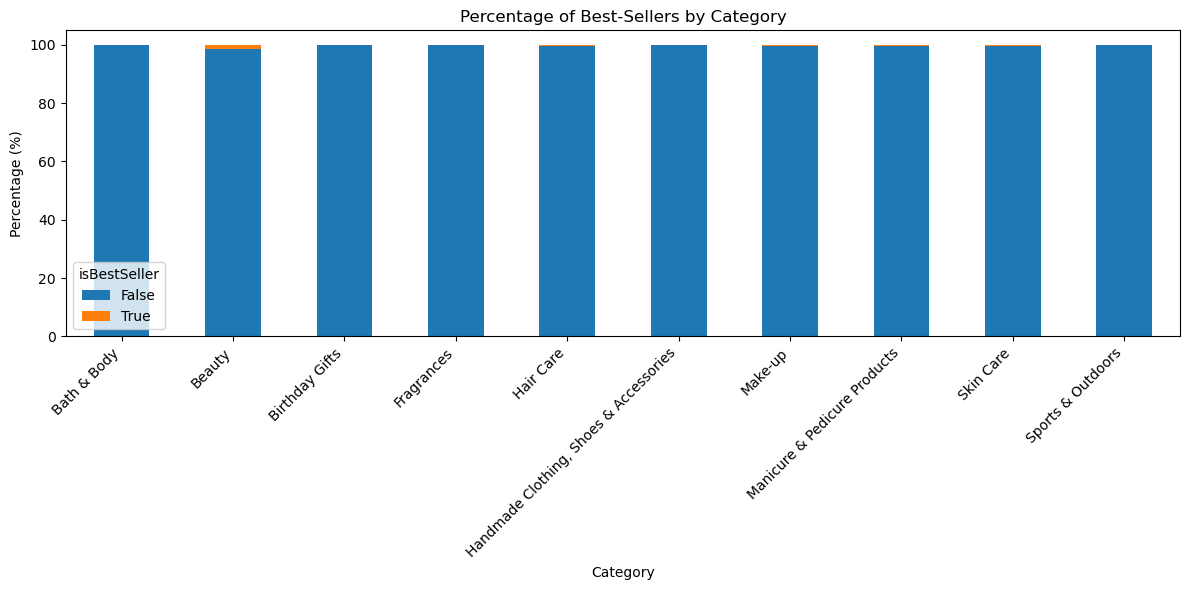

In [16]:
category_bestseller_pct = (
    category_bestseller_top.div(
        category_bestseller_top.sum(axis=1),
        axis=0
    ) * 100
)

category_bestseller_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Percentage of Best-Sellers by Category')
plt.xlabel('Category')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='isBestSeller')

plt.tight_layout()
plt.show()

In [ ]:
## Part 2: Exploring Product Prices and Ratings Across Categories and Brands

In [ ]:
## Preliminary Step: Remove outliers in product prices.

In [17]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -44.01
Upper Bound: 99.99000000000001


In [ ]:
## Remove Outliers

In [18]:
df_no_outliers = df[
    (df['price'] >= lower_bound) &
    (df['price'] <= upper_bound)
]

print("Original Shape:", df.shape)
print("Without Outliers:", df_no_outliers.shape)

Original Shape: (2443651, 9)
Without Outliers: (2115963, 9)


In [ ]:
##  Get Top 20 Categories

In [19]:
top_20_categories = (
    df_no_outliers['category']
    .value_counts()
    .head(20)
    .index
)

top_20_categories

Index(['Sports & Outdoors', 'Beauty', 'Bath & Body',
       'Manicure & Pedicure Products',
       'Handmade Clothing, Shoes & Accessories', 'Make-up', 'Skin Care',
       'Hair Care', 'Birthday Gifts', 'Handmade Gifts', 'Handmade Home Décor',
       'Luggage and travel gear', 'Women', 'Fragrances',
       'Handmade Kitchen & Dining', 'Handmade Artwork',
       'Handmade Home & Kitchen Products', 'Handmade Jewellery', 'Men',
       'Baby'],
      dtype='object', name='category')

In [ ]:
## Filter Data set

In [21]:
df_top20 = df_no_outliers[
    df_no_outliers['category'].isin(top_20_categories)
]
df_top20

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
19513,21072,B09477KHQ3,"Personalised Birthday Print Gift ""THE YEAR YOU...",4.5,763,7.99,False,900,Handmade Home & Kitchen Products
19514,21073,B0BSRFQYG8,Wax Melts 4 Bars | Build Your Own Box (Choose ...,3.9,117,6.49,True,800,Handmade Home & Kitchen Products
19515,21074,B09N9GVHV9,"Personalised Birthday Print Gift ""ON THE DAY/Y...",4.6,1155,8.99,True,600,Handmade Home & Kitchen Products
19516,21075,B0BRYGV7PQ,Fresh Wax Melts - Laundry Type Wax Melts - Str...,4.5,56,4.99,True,500,Handmade Home & Kitchen Products
19517,21076,B0B1JHB28R,Manta Makes Work Leaving Gifts | I Used to Wor...,4.7,261,9.95,True,400,Handmade Home & Kitchen Products
...,...,...,...,...,...,...,...,...,...
2429088,2806950,B0045I6SHW,Cannondale Men's Bibshort Dart Team Bike Shorts,0.0,0,99.67,False,0,Sports & Outdoors
2429089,2806951,B0045I6NZY,Cannondale Men's Baggy Fitness Bike Shorts,0.0,0,20.62,False,0,Sports & Outdoors
2429090,2806952,B003BLON3A,Pearl iZUMi Men's Phase Splice Knicker,4.3,3,59.86,False,0,Sports & Outdoors
2437153,2818782,B091HG57TP,Goodstoworld Boys Girls Tracksuit Bottoms 3D S...,4.2,554,14.99,False,0,Sports & Outdoors


In [ ]:
## Violin plot

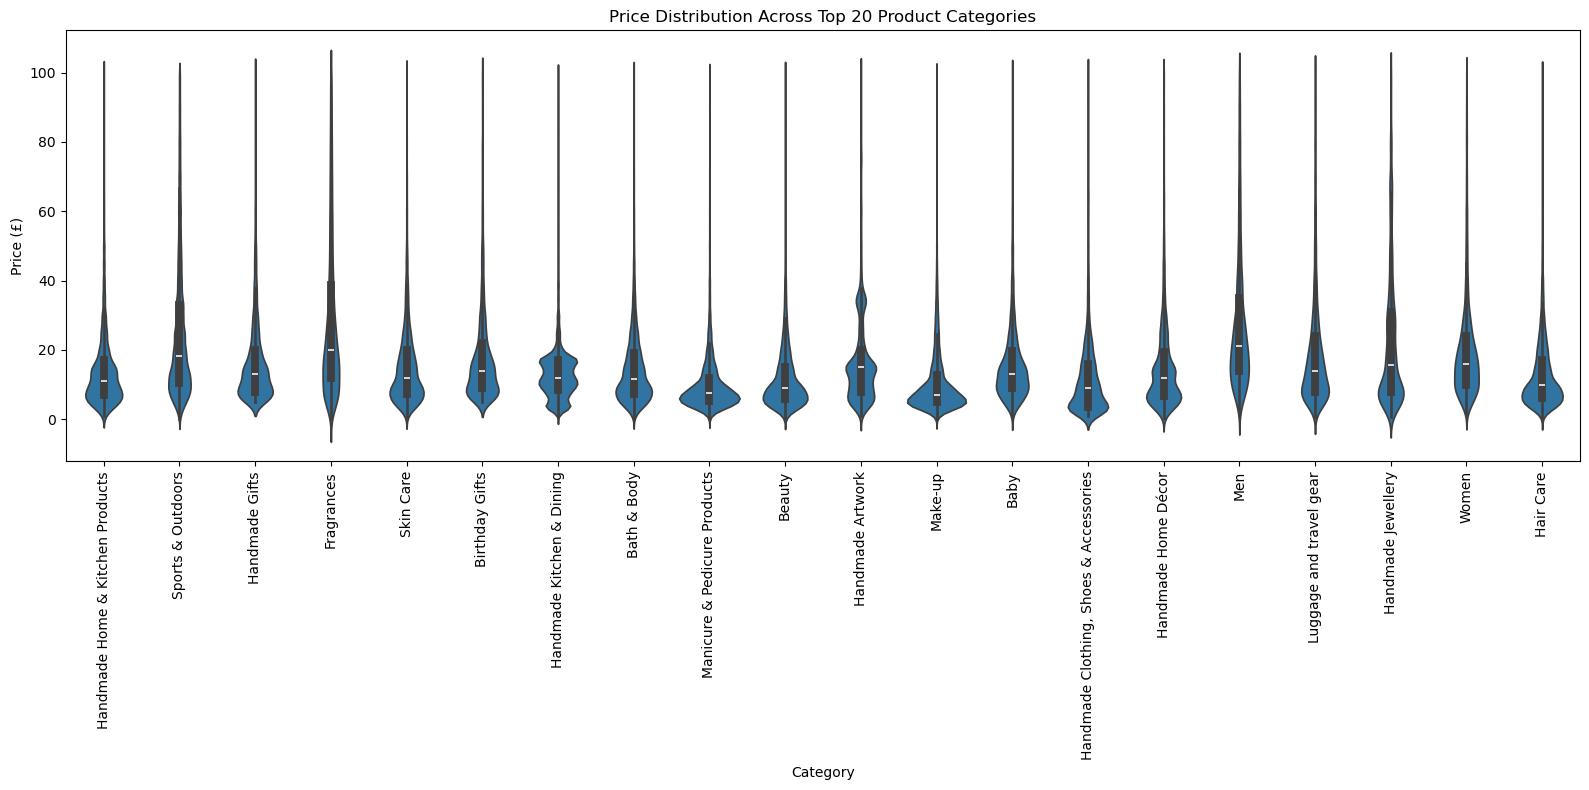

In [22]:
plt.figure(figsize=(16,8))

sns.violinplot(
    data=df_top20,
    x='category',
    y='price'
)

plt.title('Price Distribution Across Top 20 Product Categories')
plt.xlabel('Category')
plt.ylabel('Price (£)')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
## Find Category with Highest Median Price

In [23]:
median_prices = (
    df_no_outliers
    .groupby('category')['price']
    .median()
    .sort_values(ascending=False)
)

median_prices.head(10)

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

In [24]:
highest_median_category = median_prices.idxmax()
highest_median_price = median_prices.max()

print("Category:", highest_median_category)
print("Median Price:", highest_median_price)

Category: Desktop PCs
Median Price: 74.0


In [ ]:
## Bar plot

In [25]:
top_10_categories = (
    df_no_outliers['category']
    .value_counts()
    .head(10)
    .index
)

In [26]:
top10_avg_price = (
    df_no_outliers[df_no_outliers['category'].isin(top_10_categories)]
    .groupby('category')['price']
    .mean()
    .sort_values(ascending=False)
)

top10_avg_price

category
Sports & Outdoors                         25.172065
Birthday Gifts                            18.600195
Handmade Gifts                            17.395112
Skin Care                                 15.654722
Bath & Body                               14.678683
Hair Care                                 13.461408
Handmade Clothing, Shoes & Accessories    12.958639
Beauty                                    12.523480
Make-up                                   10.612918
Manicure & Pedicure Products              10.231825
Name: price, dtype: float64

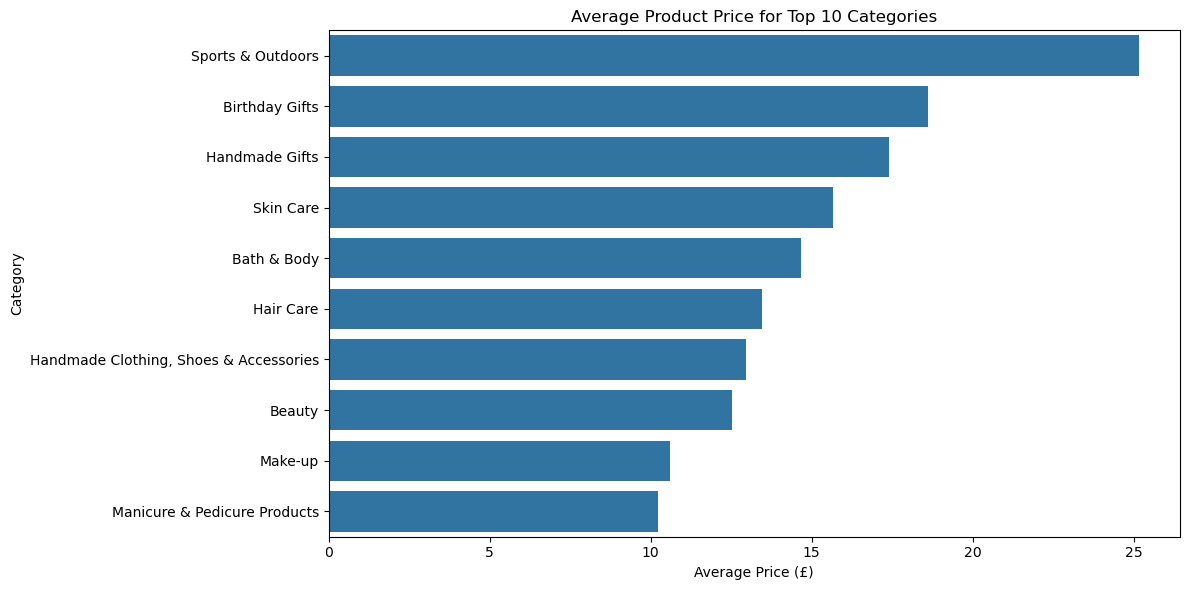

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top10_avg_price.values,
    y=top10_avg_price.index
)

plt.title('Average Product Price for Top 10 Categories')
plt.xlabel('Average Price (£)')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

In [28]:
avg_price_all_categories = (
    df_no_outliers
    .groupby('category')['price']
    .mean()
    .sort_values(ascending=False)
)

avg_price_all_categories.head(10)

category
Motherboards         68.772432
Boxing Shoes         67.417803
Desktop PCs          66.915562
Tablets              66.552971
Graphics Cards       65.103509
Digital Frames       60.745129
Streaming Clients    60.241803
Hockey Shoes         60.094796
Computer Cases       58.339884
Skiing Poles         57.867770
Name: price, dtype: float64

In [29]:
highest_avg_category = avg_price_all_categories.idxmax()
highest_avg_price = avg_price_all_categories.max()

print("Highest Average Price Category:", highest_avg_category)
print("Average Price:", round(highest_avg_price, 2))

Highest Average Price Category: Motherboards
Average Price: 68.77


In [ ]:
## Box plot

In [30]:
top_10_categories = (
    df_no_outliers['category']
    .value_counts()
    .head(10)
    .index
)

In [31]:
df_top10 = df_no_outliers[
    df_no_outliers['category'].isin(top_10_categories)
]

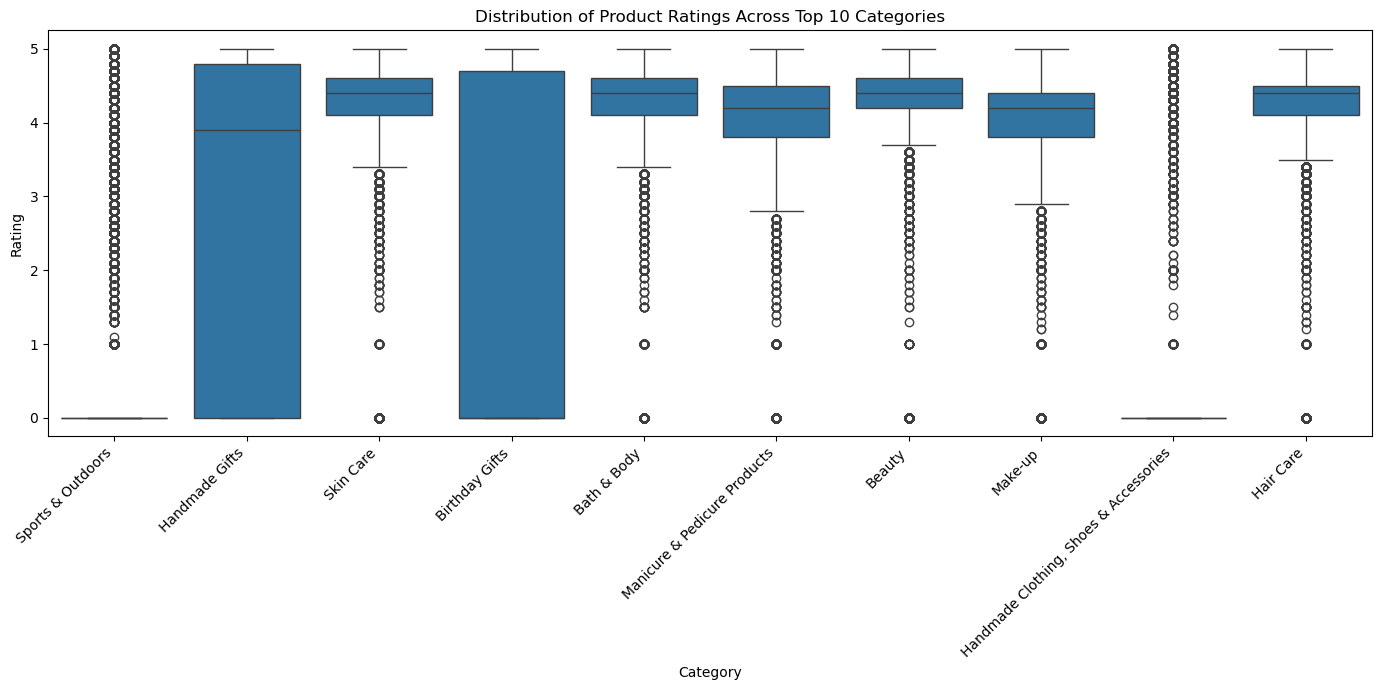

In [33]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_top10,
    x='category',
    y='stars'
)

plt.title('Distribution of Product Ratings Across Top 10 Categories')
plt.xlabel('Category')
plt.ylabel('Rating')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [35]:
median_ratings = (
    df_no_outliers
    .groupby('category')['stars']
    .median()
    .sort_values(ascending=False)
)

median_ratings.head(10)

category
Computer Memory                 4.7
Building & Construction Toys    4.6
Office Paper Products           4.6
Luxury Food & Drink             4.6
Kids' Play Figures              4.6
Hobbies                         4.6
Beer, Wine & Spirits            4.6
Laptop Accessories              4.6
Cables & Accessories            4.5
CPUs                            4.5
Name: stars, dtype: float64

In [36]:
highest_rating_category = median_ratings.idxmax()
highest_median_rating = median_ratings.max()

print("Category:", highest_rating_category)
print("Median Rating:", highest_median_rating)

Category: Computer Memory
Median Rating: 4.7


In [ ]:
## Part 3: Investigating the Interplay Between Product Prices and Ratings

In [38]:
correlation = df_no_outliers['price'].corr(df_no_outliers['stars'])

print("Correlation coefficient:", round(correlation, 4))

Correlation coefficient: -0.0777


In [39]:
df_no_outliers[['price', 'stars']].corr()

,price,stars
price,1.000000,-0.077673
stars,-0.077673,1.000000


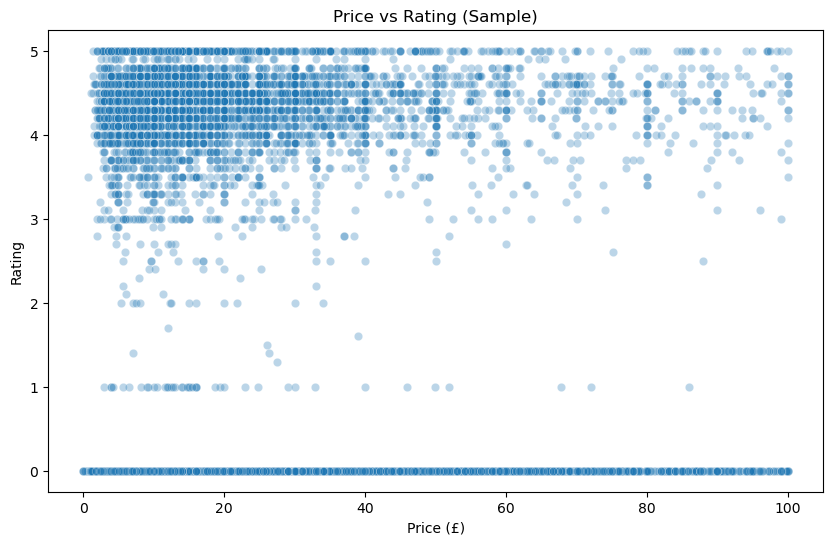

In [41]:
sample_df = df_no_outliers.sample(
    n=10000,
    random_state=42
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x='price',
    y='stars',
    alpha=0.3
)

plt.title('Price vs Rating (Sample)')
plt.xlabel('Price (£)')
plt.ylabel('Rating')

plt.show()